In [1]:
# ------------------------------------------------------------
# Random Forest on Wine dataset (sklearn)
# Steps:
# 1) Load dataset
# 2) Visualize data with labels
# 3) Standard scaling
# 4) Train-test split
# 5) Train Random Forest
# 6) Evaluate
# ------------------------------------------------------------

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# -----------------------
# 1) Load Wine dataset
# -----------------------

wine = load_wine()
x = wine.data
y = wine.target
feature_names = wine.feature_names
class_names = wine.target_names

print('x shape: ', x.shape)
print('y shape: ', y.shape)
print('Classes: ', class_names)
print('1st 3 features names: ', feature_names[:3])


x shape:  (178, 13)
y shape:  (178,)
Classes:  ['class_0' 'class_1' 'class_2']
1st 3 features names:  ['alcohol', 'malic_acid', 'ash']


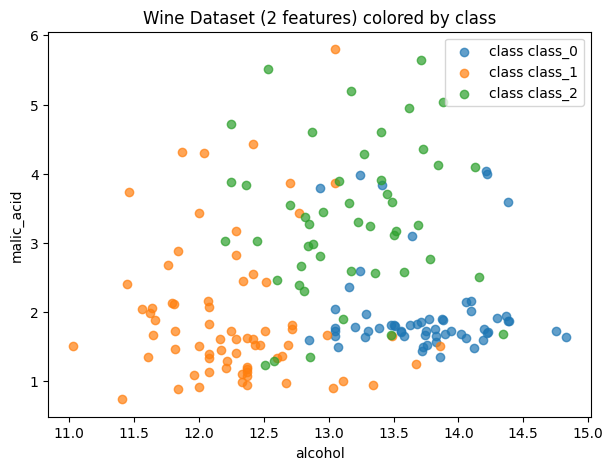

In [5]:
# ------------------------------------------------------------
# 2) Visualization: 2D scatter using two features
# ------------------------------------------------------------
# We'll use feature 0 vs feature 1 to visualize class separation

plt.figure(figsize=(7, 5))
for c in np.unique(y):
  plt.scatter(
      x[y == c, 0], x[y == c, 1],
      label =f'class {class_names[c]}',
      alpha = 0.7
  )

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title('Wine Dataset (2 features) colored by class')
plt.legend()
plt.show()

In [6]:
# -----------------------
# 3) Standard scaling
# -----------------------

scaler = StandardScaler()
x = scaler.fit_transform(x)


In [7]:
# -----------------------
# 4) Train-test split
# -----------------------

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print('Train: ', x_train.shape, y_train.shape)
print('Test: ', x_test.shape, y_test.shape)

Train:  (142, 13) (142,)
Test:  (36, 13) (36,)


In [8]:
# 4) Train model

rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [10]:
y_pred = rf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [11]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators = 200, random_state = 42, n_jobs = -1))

])

pipe.fit(x_train, y_train)
y_pred = pipe.predict(x_test)

y_pred[:2]

array([0, 2])